# LWNet (Lightweight W-Net) Vessel Segmentation
This notebook loads the LWNet model and performs vessel segmentation on 3 random images from Domain A and Domain B.

In [2]:
import os
import sys
sys.path.append('lwnet_src')
import cv2
import torch
import numpy as np
from pathlib import Path
from PIL import Image
from eval_utils import get_test_images, plot_comparison

# LWNet imports
from models.get_model import get_arch
from utils.model_saving_loading import load_model
from utils import paired_transforms_tv04 as p_tr
from predict_one_image import get_fov, crop_to_fov, create_pred

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cpu


In [3]:
# Setup Paths and Data
DATA_DIR = '../datasets/dlri/aligned'
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(exist_ok=True)

chosen_A, chosen_B = get_test_images(DATA_DIR, num_images=3)
print('Selected A images:', [p.name for p in chosen_A])
print('Selected B images:', [p.name for p in chosen_B])

Selected A images: ['7330_Complete_L_0.png', '1038_Anomalous_R_0.png', '1010_Complete_R_0.png']
Selected B images: ['7330_Complete_L_0.png', '1038_Anomalous_R_0.png', '1010_Complete_R_0.png']


In [4]:
# Load LWNet Model
model_name = 'wnet'
model_path = 'models/lwnet'

model = get_arch(model_name).to(device)
model.mode = 'eval'
model, stats = load_model(model, model_path, device)
model.eval()
print('LWNet model loaded successfully!')

LWNet model loaded successfully!


In [5]:
def segment_image_lwnet(img_path, model, device):
    img = Image.open(img_path)
    # LWNet requires an FOV mask, if none provided it computes it.
    mask = get_fov(img)
    mask_arr = np.array(mask).astype(bool)
    
    img_cropped, coords_crop = crop_to_fov(img, mask_arr)
    original_sz = img_cropped.size[1], img_cropped.size[0] # H, W
    
    # Standard preprocessing from predict_one_image.py
    tg_size = (512, 512)
    tr = p_tr.Compose([p_tr.Resize(tg_size), p_tr.ToTensor()])
    im_tens = tr(img_cropped)
    
    full_pred, full_pred_bin = create_pred(
        model, im_tens, mask_arr, coords_crop, original_sz, 
        bin_thresh=0.4196, tta='no'
    )
    return full_pred_bin

# Run segmentation
print('Running inference on Domain A...')
preds_A = [segment_image_lwnet(p, model, device) for p in chosen_A]

print('Running inference on Domain B...')
preds_B = [segment_image_lwnet(p, model, device) for p in chosen_B]

Running inference on Domain A...
Optimization terminated successfully.
         Current function value: -327885.000000
         Iterations: 53
         Function evaluations: 124
Optimization terminated successfully.
         Current function value: -327917.000000
         Iterations: 59
         Function evaluations: 130
Optimization terminated successfully.
         Current function value: -327748.000000
         Iterations: 55
         Function evaluations: 136
Running inference on Domain B...
Optimization terminated successfully.
         Current function value: -328399.000000
         Iterations: 61
         Function evaluations: 127
Optimization terminated successfully.
         Current function value: -328410.000000
         Iterations: 62
         Function evaluations: 129
Optimization terminated successfully.
         Current function value: -326542.000000
         Iterations: 59
         Function evaluations: 124


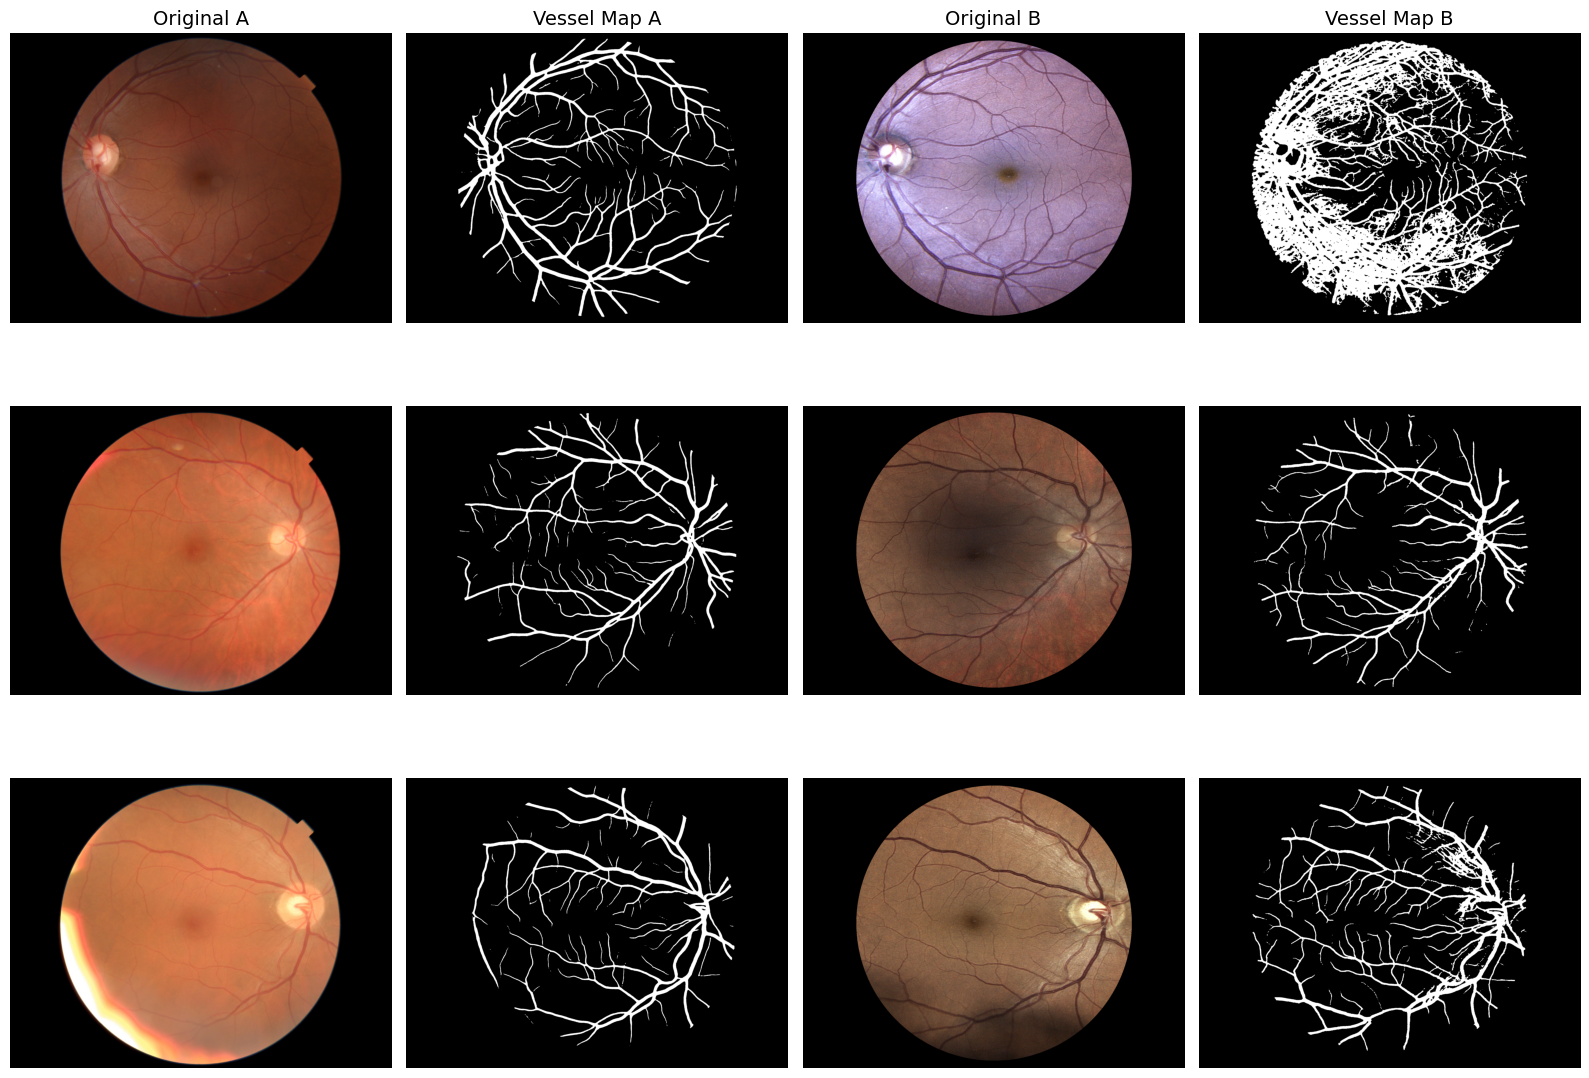

Saved visualization to results/lwnet_comparison_plot.png


In [6]:
# Plot and save results
save_path = RESULTS_DIR / 'lwnet_comparison_plot.png'
plot_comparison(chosen_A, chosen_B, preds_A, preds_B, save_path)
print(f'Saved visualization to {save_path}')